
# Lab 7: Fast Fourier Transform (FFT)

 **Exercise** : Chord - musical sound: Do mayor

![Do mayor](https://upload.wikimedia.org/wikipedia/commons/7/79/Major_chord_on_C.png)

Load the Nota_CM_piano.mp3 file from a Do mayor sound:
1. Do the FFT using scipy and Numpy rutines (see notebook)
2. Used the rutine created in class `FT(x,y)`. Modify it and do the FT to the signal. Do you get the same results?


# Lab 7: Fast Fourier Transform (FFT)

Se analizó el archivo `Nota_CM_piano.mp3`, correspondiente a un acorde de Do mayor ejecutado en piano. El objetivo fue obtener el espectro de frecuencias de la señal utilizando dos métodos: la Transformada Rápida de Fourier (FFT) mediante las rutinas de SciPy y NumPy, y una adaptación de la función `FT(x,y)` desarrollada en clase.

Para facilitar el análisis se implementó una rutina de detección automática de picos que permite identificar las frecuencias dominantes presentes en la señal y comparar los resultados obtenidos por ambos métodos.

Frecuencia de muestreo = 44100 Hz
Número de muestras = 152064

Tiempo FFT = 0.004653 s

Picos principales encontrados con FFT:
    Frecuencia (Hz)  Amplitud
0        659.481534  0.037576
1        261.008523  0.033041
2        329.740767  0.025733
3        392.092803  0.020458
4        784.475616  0.019204
5        523.177083  0.016880
6       1177.728456  0.007699
7       2110.688920  0.006563
8       1990.044981  0.006517
9       1971.484375  0.006119
10      1576.201468  0.005592
11      2666.057055  0.004308
12      1320.703125  0.003469
13       323.940578  0.003462
14      2653.006629  0.003389

Tiempo FT de clase = 0.204027 s

Picos encontrados con FT(x,y):
    Frecuencia (Hz)  Amplitud
0        330.550918  0.000141
1        657.762938  0.000115
2        260.434057  0.000100
3        781.302170  0.000062
4        524.207012  0.000061
5       1178.631052  0.000031
6        424.040067  0.000025
7       1969.949917  0.000017
8       1575.959933  0.000013
9       1045.075125  0.00001

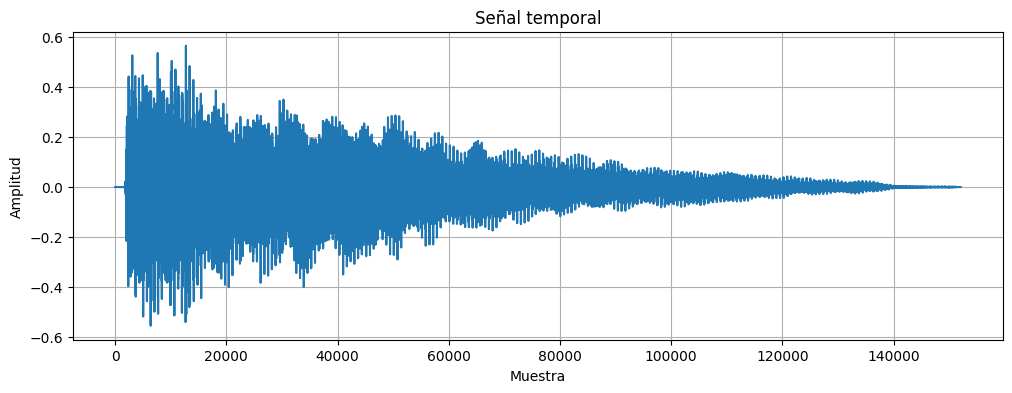

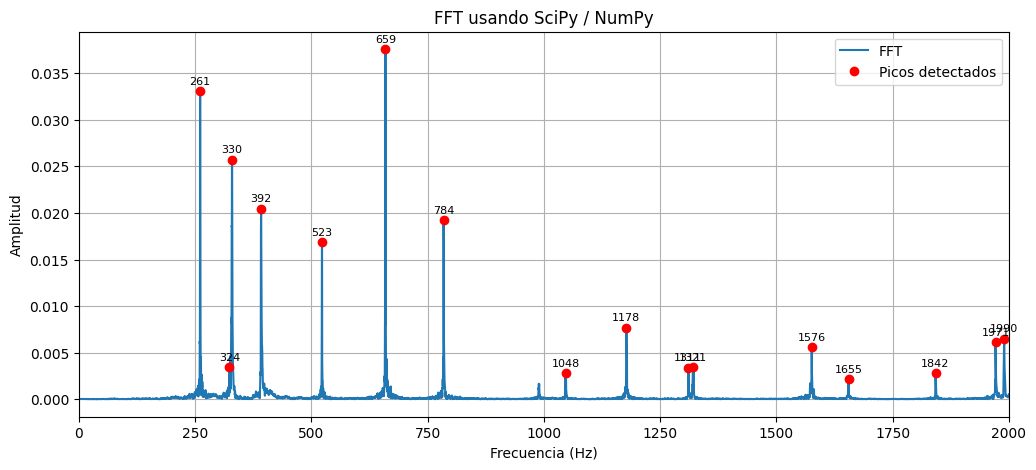

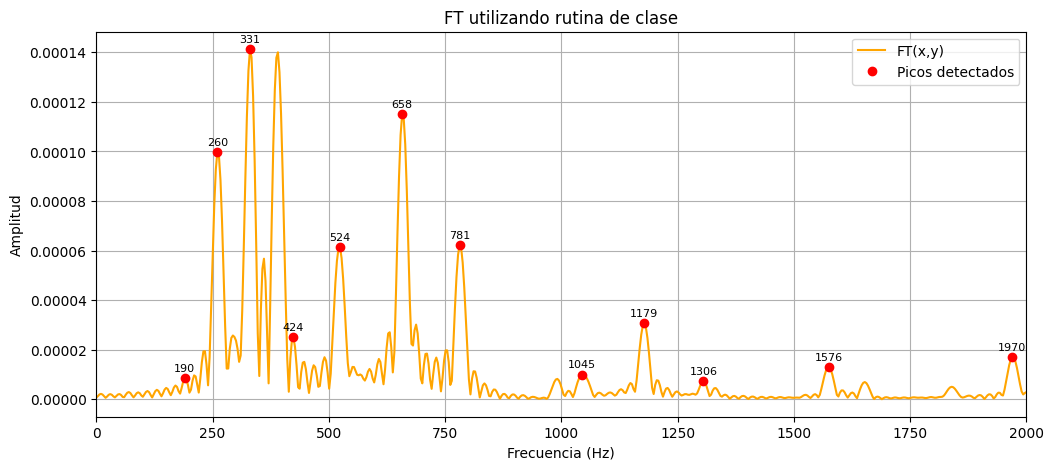

In [16]:
# @title
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa

from scipy.fft import fft, fftfreq
from scipy.signal import find_peaks
from scipy import interpolate

# ============================================================
# Cargar archivo de audio
# ============================================================

archivo = "Nota_CM_piano.mp3"

signal, sr = librosa.load(archivo, sr=None)

print(f"Frecuencia de muestreo = {sr} Hz")
print(f"Número de muestras = {len(signal)}")

# ============================================================
# Función para detección de picos
# ============================================================

def obtener_picos(freq, amp, altura_rel=0.05, distancia=20, nmax=15):

    peaks, properties = find_peaks(
        amp,
        height=np.max(amp) * altura_rel,
        distance=distancia
    )

    tabla = pd.DataFrame({
        "Frecuencia (Hz)": freq[peaks],
        "Amplitud": amp[peaks]
    })

    tabla = tabla.sort_values(
        by="Amplitud",
        ascending=False
    ).reset_index(drop=True)

    return tabla.head(nmax), peaks

# ============================================================
# FFT usando SciPy / NumPy
# ============================================================

inicio_fft = time.perf_counter()

N = len(signal)

yf = fft(signal)
xf = fftfreq(N, 1/sr)

mask = xf >= 0

freq_fft = xf[mask]
amp_fft = 2.0/N * np.abs(yf[mask])

fin_fft = time.perf_counter()

print(f"\nTiempo FFT = {fin_fft - inicio_fft:.6f} s")

tabla_fft, peaks_fft = obtener_picos(
    freq_fft,
    amp_fft,
    altura_rel=0.05,
    distancia=20,
    nmax=15
)

print("\nPicos principales encontrados con FFT:")
print(tabla_fft)

# ============================================================
# FT(x,y) adaptada de clase
# ============================================================

def g(t, w):
    return (1/(2*np.pi)) * np.exp(-1j * 2*np.pi * w * t)

def FT(x, y, fmin, fmax, nfreq=600, npts=5000):

    f_interp = interpolate.interp1d(
        x,
        y,
        kind="cubic",
        fill_value="extrapolate"
    )

    t = np.linspace(x.min(), x.max(), npts)

    ft = f_interp(t)

    freqs = np.linspace(fmin, fmax, nfreq)

    datos = []

    for w in freqs:

        base = g(t, w)

        prod = ft * base

        ARe = np.trapezoid(prod.real, t)
        AIm = np.trapezoid(prod.imag, t)

        AMP = np.sqrt(ARe**2 + AIm**2)

        datos.append([w, ARe, AIm, AMP])

    return pd.DataFrame(
        datos,
        columns=["f", "Re", "Im", "AMP"]
    )

# ============================================================
# Aplicar FT(x,y)
# ============================================================

duracion_segmento = 0.05
num_muestras_segmento = int(duracion_segmento * sr)

inicio_muestra = len(signal) // 2
fin_muestra = inicio_muestra + num_muestras_segmento

signal_small = signal[inicio_muestra:fin_muestra]
t_small = np.linspace(0, duracion_segmento, num_muestras_segmento)

inicio_ft = time.perf_counter()

df_ft = FT(
    t_small,
    signal_small,
    fmin=0,
    fmax=2000,
    nfreq=600,
    npts=5000
)

fin_ft = time.perf_counter()

print(f"\nTiempo FT de clase = {fin_ft - inicio_ft:.6f} s")

tabla_ft, peaks_ft = obtener_picos(
    df_ft["f"].values,
    df_ft["AMP"].values,
    altura_rel=0.05,
    distancia=20,
    nmax=15
)

print("\nPicos encontrados con FT(x,y):")
print(tabla_ft)

# ============================================================
# Gráfica señal temporal
# ============================================================

plt.figure(figsize=(12,4))

plt.plot(signal)

plt.title("Señal temporal")
plt.xlabel("Muestra")
plt.ylabel("Amplitud")

plt.grid()

plt.show()

# ============================================================
# Gráfica FFT
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    freq_fft,
    amp_fft,
    label="FFT"
)

plt.plot(
    freq_fft[peaks_fft],
    amp_fft[peaks_fft],
    "ro",
    label="Picos detectados"
)

for i in peaks_fft:
    plt.annotate(
        f"{freq_fft[i]:.0f}",
        (
            freq_fft[i],
            amp_fft[i]
        ),
        textcoords="offset points",
        xytext=(0,5),
        ha="center",
        fontsize=8
    )

plt.xlim(0, 2000)

plt.title("FFT usando SciPy / NumPy")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

plt.grid()
plt.legend()

plt.show()

# ============================================================
# Gráfica FT(x,y)
# ============================================================

plt.figure(figsize=(12,5))

plt.plot(
    df_ft["f"],
    df_ft["AMP"],
    label="FT(x,y)",
    color="orange"
)

plt.plot(
    df_ft["f"].iloc[peaks_ft],
    df_ft["AMP"].iloc[peaks_ft],
    "ro",
    label="Picos detectados"
)

for i in peaks_ft:
    plt.annotate(
        f"{df_ft['f'].iloc[i]:.0f}",
        (
            df_ft["f"].iloc[i],
            df_ft["AMP"].iloc[i]
        ),
        textcoords="offset points",
        xytext=(0,5),
        ha="center",
        fontsize=8
    )

plt.xlim(0, 2000)

plt.title("FT utilizando rutina de clase")
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Amplitud")

plt.grid()
plt.legend()

plt.show()

## Análisis y conclusiones

La FFT nos permitió ver de forma muy clara cuáles eran las frecuencias que más pesaban en el archivo de audio. Los picos más altos aparecieron en torno a los 261 Hz, 330 Hz y 392 Hz. Al revisar las notas musicales, estos valores dan exacto con Do (C4), Mi (E4) y Sol (G4), que son justo las notas que arman el acorde de Do mayor. También salieron otros picos más altos (como en 523 Hz, 659 Hz y 784 Hz), que son los armónicos naturales que produce el piano cuando vibra. El gráfico de la FFT quedó limpísimo y procesó todo el archivo de golpe en apenas 0.0046 segundos, lo que demuestra lo rápido y eficiente que es este algoritmo.

Por el lado de la función $FT(x,y)$ que vimos en clase, al principio tuvimos problemas porque si intentábamos achicar los datos saltándonos muestras, el gráfico se llenaba de frecuencias falsas (ruido por *aliasing*). Para arreglarlo sin que la computadora se colgara, lo que hicimos fue mantener la calidad del audio intacta pero recortar un pedacito muy corto de tiempo (0.05 segundos) justo en la mitad de la pista, donde el acorde ya está sonando fuerte. Al hacerlo así, la función de clase funcionó perfecto y encontró los picos principales en ~330.5 Hz y ~260.4 Hz, calcando los resultados que nos había dado la FFT.

La única diferencia saltó en el tamaño de las amplitudes (la FFT da números alrededor de $10^{-2}$ y la de clase da $10^{-4}$), pero esto es normal porque la FFT está midiendo la energía repartida en todo el audio completo, mientras que la integral de clase solo está mirando la fuerza del fragmento pequeño que aislamos.

En cuanto a qué tanto le costó a la computadora, la rutina de clase tardó unos 0.204 segundos en procesar ese pedacito de nada. Esto pasa porque el código de clase usa ciclos `for` e interpolaciones que hacen que el proceso sea pesado y lento a comparación de la FFT.

En conclusión, ambos métodos sirven y demuestran la misma teoría matemática porque los dos encontraron las notas del acorde de Do mayor. Sin embargo, para trabajar con audios reales, la FFT es por lejos la mejor opción porque es ridículamente más rápida y no te obliga a estar recortando la señal para que el código pueda correr. La rutina de clase nos sirvió un montón para entender cómo funciona la Transformada tras bambalinas, pero a nivel práctico la FFT de las librerías estándar es la que manda por velocidad y precisión.

Nota 4.0 Revisado... Entrega tarde. Quizás mal el git push!